# ***Ⅱ. 텍스트 데이터 처리***

## ***3. 텍스트 자료의 분류***
- 추출된 텍스트 정보를 이용하여 텍스트 자료를 분류하는 방법을 알아봅니다
- 지난 시간에는 단어가방을 하나 만들었습니다
- 이번 시간에는 긍정 단어가방과 부정 단어가방을 만들어서 진행합니다

## ***긍정 단어가방과 부정 단어가방***
- 단어의 집합이 두가지가 있습니다
- 영화를 예로 들면 아래와 같습니다
- 많은 리뷰 댓글로부터 아래와 같이 만들어볼 수 있습니다


| 범주     | 예시 단어                                                     |
| ------ | --------------------------------------------------------- |
| **긍정** | 최고, 감동, 대박, 압도적, 명작, 완벽, 레전드, 재미있다, 좋다, 몰입, 추천, 기대된다, 괜찮다 |
| **부정** | 지루하다, 아쉽다, 별로, 실망, 애매, 최악, 답답, 망작                    |


- 단어 가방이 충분하지 않다면 영화 리뷰 댓글을 찾아보고 좀더 추가해봅니다

In [1]:
# 긍정 단어 리스트
positive_words = [
    "최고", "감동", "대박", "압도적", "명작", "완벽", "레전드",
    "재미있다", "좋다", "몰입", "추천", "기대된다", "괜찮다"
]

# 부정 단어 리스트
negative_words = [
    "지루하다", "아쉽다", "별로", "실망", "애매", "최악", "답답", "망작"
]

### ***집합 기반의 유사도***

#### ***Jaccard Similarity (자카드 유사도)***
두 집합 \(A, B\)에 대해

$
\text{Jaccard}(A, B) = \frac{|A \cap B|}{|A \cup B|}
$

- 값 범위: $(0 \le \text{Jaccard}(A,B) \le 1)$
  - 1 → 완전히 동일한 집합
  - 0 → 겹치는 원소 없음

**예시:**

$
A = \{\text{apple}, \text{banana}, \text{cherry}\}
$

$
B = \{\text{banana}, \text{cherry}, \text{durian}\}
$

$
\text{Jaccard}(A, B) = \frac{| \{ \text{banana}, \text{cherry} \} |}{|\{ \text{apple}, \text{banana}, \text{cherry}, \text{durian} \}|} = \frac{2}{4} = 0.5
$

---

In [ ]:
# 자카드 유사도 함수
def jaccard_similarity(A, B):
    intersection = A.intersection(B)
    union = A.union(B)
    if not union:  # 둘 다 빈 집합이면 1로 정의
        return 1.0
    return len(intersection) / len(union)

# 예시
A = {'apple', 'banana', 'cherry'}
B = {'banana', 'cherry', 'durian'}

sim = jaccard_similarity(A, B)
print(f"Jaccard similarity: {sim:.2f}")  # Jaccard similarity: 0.50

Jaccard similarity: 0.50


#### ***영화 리뷰 2개에 대한 자카드 유사도 계산***
- 지난주에 활용했던 konlpy를 이용하여 두 문장으로부터 어근을 추출한뒤 자카드 유사도를 계산합니다

In [3]:
! pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 24.7 MB/s eta 0:00:00


In [7]:
from konlpy.tag import Okt

# 형태소 분석기 초기화
okt = Okt()

def tokenize(text):
    # 명사, 형용사, 동사 등을 어근 형태로 추출
    tokens = []
    for word, pos in okt.pos(text, stem=True):  # stem=True -> 어간 추출
        if pos in ['Noun', 'Adjective', 'Verb']:
            tokens.append(word)
    return set(tokens)

# 자카드 유사도
def jaccard_similarity(A, B):
    intersection = A.intersection(B)
    union = A.union(B)
    if not union:  # 둘 다 빈 집합이면 1로 정의
        return 1.0

    sim = len(intersection) / len(union)
    print(f"len(intersection): {len(intersection)}")
    print(f"len(union): {len(union)}")
    print(f"자카드 유사도: {sim:.2f}")

# 예시 문장
review1 = "이번 화 진짜 대박이었어요! 캐릭터들 간의 케미가 몰입하게 만들고, 연출이 압도적이라 감탄했네요. 다만 중간중간 스토리가 조금 평범한 느낌도 있었어요. 그래도 전반적으로 재미있다고 느꼈습니다."
review2 = "솔직히 이번 화는 좀 지루하다고 생각했어요. 몇몇 장면은 별로였고, 이해하기 난해한 부분도 있었네요. 그래도 그림체는 여전히 좋다고 할 수 있어요."

# 토큰화
A = tokenize(review1)
B = tokenize(review2)
print(A)
print(B)

jaccard_similarity(A, B)

{'케미', '감탄', '진짜', '조금', '이다', '느낌', '화', '연출', '다만', '대박', '간의', '재미있다', '하다', '전반', '중간', '이번', '몰입', '캐릭터', '평범하다', '있다', '스토리', '만들다', '압도', '느끼다'}
{'지루하다', '별로', '이다', '몇몇', '수', '화', '체', '그림', '장면', '이해', '하다', '생각', '이번', '좋다', '솔직하다', '여전하다', '좀', '있다', '난해하다', '부분'}
len(intersection): 5
len(union): 39
자카드 유사도: 0.13


영화 리뷰 예시 1

"이번 편은 진짜 대박이었어요! 캐릭터들 간의 케미가 몰입하게 만들고, 연출이 압도적이라 감탄했네요. 다만 중간중간 스토리가 조금 평범한 느낌도 있었어요. 그래도 전반적으로 재미있다고 느꼈습니다."

영화 리뷰 예시 2

"솔직히 이번 화는 좀 지루하다고 생각했어요. 몇몇 장면은 별로였고, 이해하기 난해한 부분도 있었네요. 그래도 그림체는 여전히 좋다고 할 수 있어요."

영화 리뷰 예시 3

"와… 이번 웹툰 완전 명작이에요. 스토리, 그림, 연출 다 완벽하고, 매 화마다 감동이 몰려옵니다. 진짜 레전드 웹툰 인정합니다!"

### ***리뷰 텍스트와 긍정 단어가방의 유사도***

In [9]:
from konlpy.tag import Okt

# 형태소 분석기 초기화
okt = Okt()

# 예시 문장
review1 = "이번 화 진짜 대박이었어요! 캐릭터들 간의 케미가 몰입하게 만들고, 연출이 압도적이라 감탄했네요. 다만 중간중간 스토리가 조금 평범한 느낌도 있었어요. 그래도 전반적으로 재미있다고 느꼈습니다."

# 토큰화
A = tokenize(review1)
B = positive_words
print(A)
print(B)

jaccard_similarity(A, B)

{'케미', '감탄', '진짜', '조금', '이다', '느낌', '화', '연출', '다만', '대박', '간의', '재미있다', '하다', '전반', '중간', '이번', '몰입', '캐릭터', '평범하다', '있다', '스토리', '만들다', '압도', '느끼다'}
['최고', '감동', '대박', '압도적', '명작', '완벽', '레전드', '재미있다', '좋다', '몰입', '추천', '기대된다', '괜찮다']
len(intersection): 3
len(union): 34
자카드 유사도: 0.09


### ***리뷰 텍스트와 부정 단어가방의 유사도***

In [10]:
from konlpy.tag import Okt

# 형태소 분석기 초기화
okt = Okt()

# 예시 문장
review1 = "이번 화 진짜 대박이었어요! 캐릭터들 간의 케미가 몰입하게 만들고, 연출이 압도적이라 감탄했네요. 다만 중간중간 스토리가 조금 평범한 느낌도 있었어요. 그래도 전반적으로 재미있다고 느꼈습니다."

# 토큰화
A = tokenize(review1)
B = negative_words
print(A)
print(B)

jaccard_similarity(A, B)

{'케미', '감탄', '진짜', '조금', '이다', '느낌', '화', '연출', '다만', '대박', '간의', '재미있다', '하다', '전반', '중간', '이번', '몰입', '캐릭터', '평범하다', '있다', '스토리', '만들다', '압도', '느끼다'}
['지루하다', '아쉽다', '별로', '실망', '애매', '최악', '답답', '망작']
len(intersection): 0
len(union): 32
자카드 유사도: 0.00


### ***반어법을 사용한 리뷰***
- 아래와 같은 리뷰와 긍정 단어가방간의 자카드유사로를 위의 결과와 비교해봅시다
- 이러한 반어법을 사용한 리뷰의 점수를 걸러내기 어렵게 됩니다

In [17]:
from konlpy.tag import Okt

# 형태소 분석기 초기화
okt = Okt()

# 예시 문장
review5 = "이건 정말 대박이다. 정말 추천 모든게 완벽 명작 그자체 레전드임. 너무 감동적이어서 100점을 주고 싶은데 만점이 고작 10점이라니 슬픔에 사무쳐서 나도 울고 컴퓨터도 울고 컴퓨터속의 악성코드도 울었다."

# 토큰화
A = tokenize(review5)
B = positive_words
print(A)
print(B)

jaccard_similarity(A, B)

{'고작', '정말', '만점', '악성코드', '울', '싶다', '대박', '사무치다', '추천', '감동', '자체', '울다', '주다', '명작', '속', '나다', '완벽', '슬픔', '임', '컴퓨터', '레전드', '점', '이건', '모든'}
['최고', '감동', '대박', '압도적', '명작', '완벽', '레전드', '재미있다', '좋다', '몰입', '추천', '기대된다', '괜찮다']
len(intersection): 6
len(union): 31
자카드 유사도: 0.19


## ***벡터의 성질과 유사도***

### ***유클리드 유사도(유클리드 거리)***
- 얼마나 떨어져 있는지 측정합니다
- 0에 가까울수록 유클리드 거리가 가깝습니다

$
d(A, B) = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + \cdots}
$

In [ ]:
import numpy as np

A = np.array([1, 2, 3])
B = np.array([2, 3, 4])

distance = np.linalg.norm(A - B)
print(distance)

1.7320508075688772


### ***길이가 다른 두 벡터의 거리 시각화***

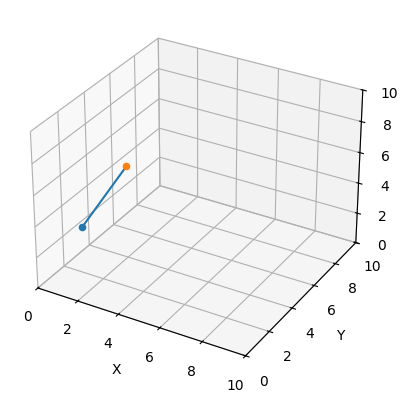

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([1, 2, 3])
B = np.array([2, 4, 6])

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.set_xlim([0, 10])
ax.set_ylim([0, 10])
ax.set_zlim([0, 10])

# 점 찍기
ax.scatter(A[0], A[1], A[2])
ax.scatter(B[0], B[1], B[2])

# 두 점 연결 (유클리드 거리)
ax.plot([A[0], B[0]],
        [A[1], B[1]],
        [A[2], B[2]])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

In [ ]:
! pip install scikit-learn

#### ***텍스트를 이용한 유클리드 유사도 계산***
- 빈도수 기반으로 문장을 벡터화 하는 라이브러리를 사용하겠습니다
- 문장 리스트를 넘기면 문장들에 존재하는 단어들을 기반으로 벡터화 합니다

In [32]:
from konlpy.tag import Okt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import euclidean_distances

# 형태소 분석기
okt = Okt()

# 어근 추출 + 품사 필터링 함수
def tokenize(text):
    tokens = []
    for word, pos in okt.pos(text, stem=True):  # stem=True -> 어근
        if pos in ['Noun', 'Adjective', 'Verb']:  # 의미 있는 단어만
            tokens.append(word)
    return tokens

# 예시 문장 (너무나 온도가 다른 문장)
review1 = "이번 화 진짜 대박이었어요! 캐릭터들 간의 케미가 몰입하게 만들고, 연출이 압도적이라 감탄했네요. 다만 중간중간 스토리가 조금 평범한 느낌도 있었어요. 그래도 전반적으로 재미있다고 느꼈습니다."
review2 = "솔직히 이번 화는 좀 지루하다고 생각했어요. 몇몇 장면은 별로였고, 이해하기 난해한 부분도 있었네요. 그래도 그림체는 여전히 좋다고 할 수 있어요."


# 예시 (비슷한 온도의 문장)
# review1 = "이번 화 정말 재미있었어요! 캐릭터들 간의 케미와 연출 덕분에 몰입감이 좋았고, 스토리도 전반적으로 흥미로웠습니다."
# review2 = "이번 화는 전반적으로 재미있었어요! 캐릭터들 케미와 연출이 좋았고, 일부 장면은 조금 평범했지만 그림체와 전체적인 분위기는 만족스러웠습니다."

sentences = [' '.join(tokenize(review1)), ' '.join(tokenize(review2))]

# CountVectorizer에 사용자 토큰화 함수 전달
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(sentences).toarray()

# 벡터화 후 feature 이름 확인
feature_names = vectorizer.get_feature_names_out()
print("원본문장", sentences)
print()
print("벡터 축(단어) 순서:\n", feature_names)
print()
print("단어 벡터:\n", X)

# 각 문장별 단어 등장 횟수 출력
for i, sentence_vec in enumerate(X):
    print(f"\n문장 {i+1} 단어 등장 횟수:")
    for word, count in zip(feature_names, sentence_vec):
        if count > 0:
            print(f"  {word}: {count}")

# 유클리드 거리 계산
dist = euclidean_distances(X)
print("유클리드 거리:\n", dist)

원본문장 ['이번 화 정말 재미있다 캐릭터 간의 케미 연출 덕분 몰입 감 좋다 스토리 전반 흥미롭다', '이번 화 전반 재미있다 캐릭터 케미 연출 좋다 일부 장면 조금 평범하다 그림 체 전체 분위기 만족스럽다']

벡터 축(단어) 순서:
 ['간의' '그림' '덕분' '만족스럽다' '몰입' '분위기' '스토리' '연출' '이번' '일부' '장면' '재미있다' '전반'
 '전체' '정말' '조금' '좋다' '캐릭터' '케미' '평범하다' '흥미롭다']

단어 벡터:
 [[1 0 1 0 1 0 1 1 1 0 0 1 1 0 1 0 1 1 1 0 1]
 [0 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0]]

문장 1 단어 등장 횟수:
  간의: 1
  덕분: 1
  몰입: 1
  스토리: 1
  연출: 1
  이번: 1
  재미있다: 1
  전반: 1
  정말: 1
  좋다: 1
  캐릭터: 1
  케미: 1
  흥미롭다: 1

문장 2 단어 등장 횟수:
  그림: 1
  만족스럽다: 1
  분위기: 1
  연출: 1
  이번: 1
  일부: 1
  장면: 1
  재미있다: 1
  전반: 1
  전체: 1
  조금: 1
  좋다: 1
  캐릭터: 1
  케미: 1
  평범하다: 1
유클리드 거리:
 [[0.         3.74165739]
 [3.74165739 0.        ]]


### ***코사인 유사도***
- 방향이 같은지 측정합니다

    $
    \cos(\theta) = \frac{A \cdot B}{\|A\| \cdot \|B\|}
    $

- **Cosine similarity = 1**  
  $\theta = 0^\circ$  → 두 벡터가 완전히 같은 방향 (정규화하면 동일 방향)
  

- **Cosine similarity = 0**  
  $\theta = 90^\circ$  → 두 벡터가 직교, 즉 방향이 완전히 다름

- **Cosine similarity = -1**  
  $\theta = 180^\circ$ → 두 벡터가 정반대 방향

In [ ]:
import numpy as np

A = np.array([1, 2, 3])

cos_sim = np.dot(A, A) / (np.linalg.norm(A) * np.linalg.norm(A))
print("코사인 유사도:", cos_sim)

코사인 유사도: 1.0


### ***방향이 같은 두 벡터의 시각화***

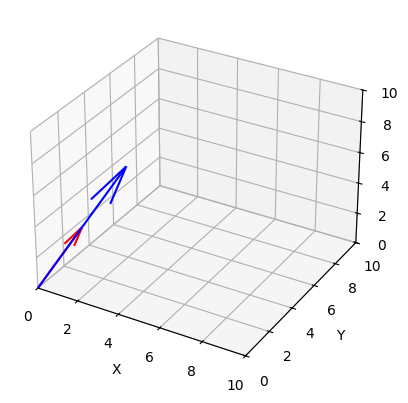

In [33]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([1, 2, 3])

B = np.array([2, 4, 6])

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# 원점
origin = [0, 0, 0]

# 동일 벡터 두 개 (겹쳐 보임)
ax.quiver(*origin, *A, color='red')
ax.quiver(*origin, *B, color='blue')

ax.set_xlim([0, 10])
ax.set_ylim([0, 10])
ax.set_zlim([0, 10])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

#### ***텍스트를 이용한 코사인 유사도 계산***

In [38]:
from konlpy.tag import Okt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 형태소 분석기
okt = Okt()

# 어근 추출 + 품사 필터링 함수
def tokenize(text):
    tokens = []
    for word, pos in okt.pos(text, stem=True):  # stem=True -> 어근
        if pos in ['Noun', 'Adjective', 'Verb']:  # 의미 있는 단어만
            tokens.append(word)
    return tokens

# 예시 문장 (너무나 온도가 다른 문장)
review1 = "이번 화 진짜 대박이었어요! 캐릭터들 간의 케미가 몰입하게 만들고, 연출이 압도적이라 감탄했네요. 다만 중간중간 스토리가 조금 평범한 느낌도 있었어요. 그래도 전반적으로 재미있다고 느꼈습니다."
review2 = "솔직히 이번 화는 좀 지루하다고 생각했어요. 몇몇 장면은 별로였고, 이해하기 난해한 부분도 있었네요. 그래도 그림체는 여전히 좋다고 할 수 있어요."


# 예시 (비슷한 온도의 문장)
# review1 = "이번 화 정말 재미있었어요! 캐릭터들 간의 케미와 연출 덕분에 몰입감이 좋았고, 스토리도 전반적으로 흥미로웠습니다."
# review2 = "이번 화는 전반적으로 재미있었어요! 캐릭터들 케미와 연출이 좋았고, 일부 장면은 조금 평범했지만 그림체와 전체적인 분위기는 만족스러웠습니다."

sentences = [' '.join(tokenize(review1)), ' '.join(tokenize(review2))]

# CountVectorizer에 사용자 토큰화 함수 전달
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(sentences).toarray()

# 벡터화 후 feature 이름 확인
feature_names = vectorizer.get_feature_names_out()
print("원본문장", sentences)
print()
print("벡터 축(단어) 순서:\n", feature_names)
print()
print("단어 벡터:\n", X)

# 각 문장별 단어 등장 횟수 출력
for i, sentence_vec in enumerate(X):
    print(f"\n문장 {i+1} 단어 등장 횟수:")
    for word, count in zip(feature_names, sentence_vec):
        if count > 0:
            print(f"  {word}: {count}")

# 코사인 유사도
cos_sim = cosine_similarity(X)
print("코사인 유사도:\n", cos_sim)

원본문장 ['이번 화 정말 재미있다 캐릭터 간의 케미 연출 덕분 몰입 감 좋다 스토리 전반 흥미롭다', '이번 화 전반 재미있다 캐릭터 케미 연출 좋다 일부 장면 조금 평범하다 그림 체 전체 분위기 만족스럽다']

벡터 축(단어) 순서:
 ['간의' '그림' '덕분' '만족스럽다' '몰입' '분위기' '스토리' '연출' '이번' '일부' '장면' '재미있다' '전반'
 '전체' '정말' '조금' '좋다' '캐릭터' '케미' '평범하다' '흥미롭다']

단어 벡터:
 [[1 0 1 0 1 0 1 1 1 0 0 1 1 0 1 0 1 1 1 0 1]
 [0 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0]]

문장 1 단어 등장 횟수:
  간의: 1
  덕분: 1
  몰입: 1
  스토리: 1
  연출: 1
  이번: 1
  재미있다: 1
  전반: 1
  정말: 1
  좋다: 1
  캐릭터: 1
  케미: 1
  흥미롭다: 1

문장 2 단어 등장 횟수:
  그림: 1
  만족스럽다: 1
  분위기: 1
  연출: 1
  이번: 1
  일부: 1
  장면: 1
  재미있다: 1
  전반: 1
  전체: 1
  조금: 1
  좋다: 1
  캐릭터: 1
  케미: 1
  평범하다: 1
코사인 유사도:
 [[1.         0.50128041]
 [0.50128041 1.        ]]


## ***유클리드 유사도 vs 코사인 유사도***

### ***유클리드 거리 기반 유사도***
- 정의: 두 벡터 사이 **직선 거리**

  $
  d(\mathbf{A}, \mathbf{B}) = \|\mathbf{A} - \mathbf{B}\| = \sqrt{\sum_i (A_i - B_i)^2}
  $
- 특징:
  - 벡터 크기(길이) 차이에 민감
  - 방향보다는 절대적 위치 차이를 측정
  - 값이 작을수록 유사함

---

### ***코사인 유사도***
- 정의: 두 벡터 사이 **방향 유사도**

  $
  \text{cosine similarity}(\mathbf{A}, \mathbf{B}) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\|\|\mathbf{B}\|} = \cos \theta
  $
- 특징:
  - 벡터 길이 차이에 영향 없음
  - 방향이 얼마나 같은지 측정
  - 값이 1에 가까울수록 방향이 유사

---

### ***비교 요약***

| 구분 | 유클리드 | 코사인 |
|------|----------|--------|
| 측정 | 절대 거리 | 방향 각도 |
| 민감도 | 벡터 크기 | 벡터 크기 무관 |
| 값 의미 | 작을수록 유사 | 1에 가까울수록 유사 |
| 장점 | 벡터의 차원이 작을 때 유리 | 벡터의 차원이 클 때 유리 |
| 사용 예 | 좌표 위치, 이미지 차이 | 문서 임베딩, 텍스트 유사도 |

## ***텍스트 마이닝***

## ***라이브러리 형태로 배포된 한국어 감성사전 사용하기***
- 단어별 긍정/부정 점수를 정의함에 따라 결과는 달라질 수 있음을 확인합니다
- 아래 코드를 다운로드 받고 실행하면서 위에 정의된 긍정, 부정 가방과 비교해봅시다
- https://github.com/park1200656/KnuSentiLex

In [ ]:
! git clone https://github.com/park1200656/KnuSentiLex.git

Cloning into 'KnuSentiLex'...
remote: Enumerating objects: 45, done.
remote: Total 45 (delta 0), reused 0 (delta 0), pack-reused 45 (from 1)
Receiving objects: 100% (45/45), 380.68 KiB | 14.10 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [ ]:
import os

if 'KnuSentiLex' not in os.getcwd():
    os.chdir('KnuSentiLex')

import knusl as ksl

try:
    while(True):
        wordname = input("단어를 입력하세요: ")
        wordname = wordname.strip(" ")
        if wordname != "종료":
            print(ksl.KnuSL.data_list(wordname))
            print("\n")
        elif wordname == "종료":
            break

except:
    print("종료!!")
    if 'KnuSentiLex' in os.getcwd():
        os.chdir('..')

finally:
    print("종료!!!")
    if 'KnuSentiLex' in os.getcwd():
        os.chdir('..')


단어를 입력하세요: 지루하다
어근 : 지루
극성 : -1
('지루', '-1')


단어를 입력하세요: 감동적이다
어근 : None
극성 : None
('None', 'None')


단어를 입력하세요: 감동
어근 : 감동
극성 : 2
('감동', '2')


종료!!
종료!!!


## ***코사인 유사도를 이용하여 문장 완성하기***
- "___는 귀엽다" 라는 문장을 완성하기 위해 "귀엽다" 와 가장 유사한 단어를 찾습니다

In [91]:
word = '귀엽다'
cute_vec = (0, 0, 1)
print(f"'{word}' 벡터:\n", cute_vec)

word = '고양이'
cat_vec = (1, 0, 2)
print(f"'{word}' 벡터:\n", cat_vec)

word = '강아지'
dog_vec = (0, 2, 1)
print(f"'{word}' 벡터:\n", dog_vec)

word = '물고기'
fish_vec = (1, 1, 2)
print(f"'{word}' 벡터:\n", fish_vec)

def get_cos_sim(A, B):
    cos_sim = np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))
    return cos_sim

print("귀엽다와 고양이 코사인 유사도:", get_cos_sim(cute_vec, cat_vec))
print("귀엽다와 강아지 코사인 유사도:", get_cos_sim(cute_vec, dog_vec))
print("귀엽다와 물고기 코사인 유사도:", get_cos_sim(cute_vec, fish_vec))

'귀엽다' 벡터:
 (0, 0, 1)
'고양이' 벡터:
 (1, 0, 2)
'강아지' 벡터:
 (0, 2, 1)
'물고기' 벡터:
 (1, 1, 2)
귀엽다와 고양이 코사인 유사도: 0.8944271909999159
귀엽다와 강아지 코사인 유사도: 0.4472135954999579
귀엽다와 물고기 코사인 유사도: 0.8164965809277261


### ***Word2Vec활용하기***
- 위의 벡터는 어떻게 만드는 것일까요?
- 주어진 문장의 주변 단어를 고려하여 벡터를 만들어주는 Word2Vec을 사용해봅니다
- 이는 주어진 문장의 의미에 따라 벡터가 달라짐을 의미합니다

In [41]:
! pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.9 MB/s eta 0:00:00


In [90]:
from konlpy.tag import Okt
from gensim.models import Word2Vec

# 예시 한국어
reviews = [
    "시립대 마스코트 고양이 건공이를 아시나요? 표정은 항상 시크하지만 사람을 너무나 좋아하는 귀엽고 사랑스러운 고양이 입니다. 건공이를 마주치면 눈높이를 맞춰 바라봐보세요. 꼬리를 세우고 다가와서 안기는 고양이의 귀여운 모습에 그냥 쓰러집니다 ㅋㅋㅋ",
    "우리집 강아지 눈에는 제가 서열 최하위에요",
    "물고기는 불포화지방이 풍부하여 건강에도 좋은 음식입니다"
]

# 형태소 분석기
okt = Okt()

def tokenize(text):
    tokens = []
    for word, pos in okt.pos(text, stem=True):
        if pos in ['Noun', 'Adjective', 'Verb']:
            tokens.append(word)
    return tokens

# 토큰화
tokenized_reviews = [tokenize(r) for r in reviews]
print("토큰화 결과:", tokenized_reviews)

# Word2Vec 학습
# size=5: 임베딩 차원, window=3: 주변 단어 고려 범위, min_count=1: 최소 빈도 단어 포함
model = Word2Vec(sentences=tokenized_reviews, vector_size=5, window=5, min_count=1, sg=1)  # sg=1 -> Skip-gram
# 모델에 학습된 단어 전체 리스트
words = list(model.wv.index_to_key)  # gensim 4.x 기준
print("학습된 단어 수:", len(words))
print("학습된 단어:", words)

# 단어 벡터 확인
word = '귀엽다'
cute_vec = model.wv[word]
print(f"'{word}' 벡터:\n", cute_vec)

word = '고양이'
cat_vec = model.wv[word]
print(f"'{word}' 벡터:\n", cat_vec)

word = '강아지'
dog_vec = model.wv[word]
print(f"'{word}' 벡터:\n", dog_vec)

word = '물고기'
fish_vec = model.wv[word]
print(f"'{word}' 벡터:\n", fish_vec)

def get_cos_sim(A, B):
    cos_sim = np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))
    return cos_sim

print("귀엽다와 고양이 코사인 유사도:", get_cos_sim(cute_vec, cat_vec))
print("귀엽다와 강아지 코사인 유사도:", get_cos_sim(cute_vec, dog_vec))
print("귀엽다와 물고기 코사인 유사도:", get_cos_sim(cute_vec, fish_vec))

토큰화 결과: [['시립대', '마스코트', '고양이', '건', '공이', '알다', '표정', '항상', '시크', '사람', '좋아하다', '귀엽다', '사랑스럽다', '고양이', '이다', '건', '공이', '마주치다', '눈높이', '맞추다', '바라보다', '보다', '꼬리', '세우다', '다가오다', '안기다', '고양이', '귀엽다', '모습', '그냥', '쓰러지다'], ['우리', '집', '강아지', '눈', '제', '서열', '최', '하위'], ['물고기', '불', '포화지방', '풍부하다', '건강', '좋다', '음식', '이다']]
학습된 단어 수: 41
학습된 단어: ['고양이', '이다', '귀엽다', '공이', '건', '음식', '좋다', '건강', '풍부하다', '포화지방', '불', '물고기', '하위', '최', '서열', '제', '눈', '강아지', '집', '우리', '쓰러지다', '그냥', '모습', '안기다', '다가오다', '세우다', '꼬리', '보다', '바라보다', '맞추다', '눈높이', '마주치다', '사랑스럽다', '좋아하다', '사람', '시크', '항상', '표정', '알다', '마스코트', '시립대']
'귀엽다' 벡터:
 [ 0.1476101  -0.03066943 -0.09073226  0.13108103 -0.09720321]
'고양이' 벡터:
 [-0.01081237  0.00466116  0.10204525  0.18018852 -0.18608695]
'강아지' 벡터:
 [ 0.03752608  0.1217795  -0.09579887 -0.06202448  0.13607085]
'물고기' 벡터:
 [-0.08924353  0.09035001 -0.1357392  -0.07096978  0.18797016]
귀엽다와 고양이 코사인 유사도: 0.45922828
귀엽다와 강아지 코사인 유사도: -0.20703693
귀엽다와 물고기 코사인 유사도: -0.4750073
